# 3 Qubit Bit Flip

# Project 10a: 3-Qubit Bit-Flip Error Correction

**Objective:** Build a redundant quantum circuit that can detect and correct an artificial `X` (bit-flip) error without measuring the primary qubit directly.

**Theory:**
In classical computing, if you want to protect a bit from corruption, you just copy it: `0` becomes `000`. If a stray cosmic ray flips one bit to `010`, the computer takes a majority vote and corrects it back to `000`.

In quantum computing, **the No-Cloning Theorem states we cannot copy an unknown quantum state**. Furthermore, if we measure the state to check for errors, we collapse its superposition and destroy the data! 

**The Solution:** We use `CNOT` gates to entangle our primary data qubit with two "ancilla" (helper) qubits, spreading the information across all three. If an error occurs, we can measure the *parity* (the mathematical relationships) of the qubits without measuring the actual data, allowing us to reverse the error perfectly.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Environment Ready.")

Environment Ready.


## Step 1: Encoding and Injecting the Error

We will prepare our primary data qubit (Qubit 0) in the $|1\rangle$ state.
We then use `CNOT` gates to entangle it with Qubits 1 and 2. 
Finally, we will intentionally inject an $X$-gate (a bit flip) on Qubit 1 to simulate a hardware error.

Circuit with Encoding and Error:


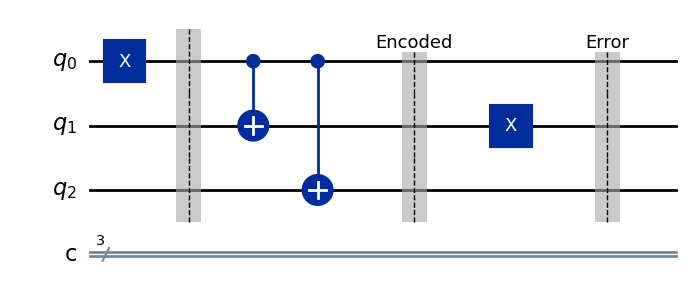

In [2]:
# 3 Data Qubits, 3 Classical Bits
qc = QuantumCircuit(3, 3)

# 1. State Preparation: Let's protect the |1> state
qc.x(0)
qc.barrier()

# 2. The Encoding: Spread the state into a 3-qubit logical state
qc.cx(0, 1)
qc.cx(0, 2)
qc.barrier(label="Encoded")

# 3. The Error: A stray X-gate hits Qubit 1!
qc.x(1)
qc.barrier(label="Error")

print("Circuit with Encoding and Error:")
display(qc.draw('mpl'))

## Step 2: Decoding and Correcting

To fix the error without looking at the data, we apply the `CNOT` gates again to uncompute the entanglement.
Then, we use a **Toffoli gate (CCX)**. The Toffoli checks Qubits 1 and 2. If they disagree with Qubit 0 (indicating an error occurred), the Toffoli automatically applies an $X$-gate to Qubit 0, flipping it back to safety!

Full Error Correction Circuit:


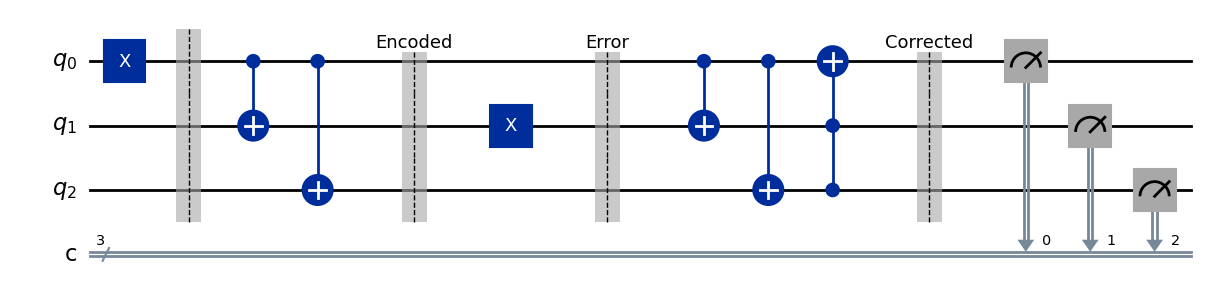

In [3]:
# 4. The Decoding (Syndrome Measurement)
qc.cx(0, 1)
qc.cx(0, 2)

# 5. The Correction (Toffoli Gate)
# If Qubit 1 and 2 trigger the Toffoli, it flips Qubit 0 back to safety
qc.ccx(1, 2, 0)
qc.barrier(label="Corrected")

# 6. Measure all three to verify
qc.measure([0, 1, 2], [0, 1, 2])

print("Full Error Correction Circuit:")
display(qc.draw('mpl'))

## Step 3: Execution and Verification

If our circuit works, Qubit 0 should measure as a `1` with 100% probability, proving our data survived the attack on Qubit 1.

Measurement Results: {'011': 1000}


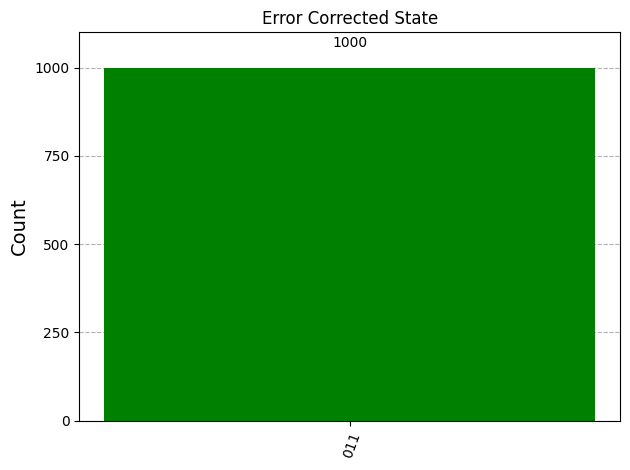

In [4]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1000)
counts = job.result()[0].data.c.get_counts()

print(f"Measurement Results: {counts}")
display(plot_histogram(counts, title="Error Corrected State", color="green"))

## Final Analysis
**What did we observe?**
Despite directly injecting a bit-flip error into the middle of our circuit, the final measurement outputs `011` (remember Qiskit reads right to left: Qubit 0 is `1`, Qubit 1 is `1` (because of the uncorrected error left over on the helper wire), Qubit 2 is `0`). 

The most important part: **Qubit 0 survived.** The original data `1` was perfectly preserved because the un-computing and Toffoli gate automatically detected the anomaly and reversed it.